# AI for Communication and Marketing – Lab Exam Part 1
**Dataset:** `marketing_campaign.csv`  

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_csv('marketing_campaign.csv', sep=None, engine='python')
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Loaded: 2240 rows × 27 columns


,﻿ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,0,0,0,0,0


---
## Task A – Data Audit & Quality

### A1. Column Name Cleanup

In [79]:
df.rename(columns={df.columns[0]: 'ID'}, inplace=True)
print('Columns:', df.columns.tolist())

Columns: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']


### A2. Missing Values

In [80]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Missing values:\n', missing)

# Decision: impute with median – robust to the extreme outlier we will find below
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)
print(f'\nImputed {missing["Income"]} missing Income values with median = {income_median:,.0f}')
print('Remaining missing values:', df.isnull().sum().sum())

Missing values:
 Income    24
dtype: int64

Imputed 24 missing Income values with median = 51,382
Remaining missing values: 0


### A3. Duplicate Rows

In [81]:
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}') if duplicates > 0 else print('No duplicate rows')

No duplicate rows


### A4. Data Type Inconsistencies

In [82]:
print(df.dtypes)

# Dt_Customer is stored as string – convert to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
print('\nDt_Customer dtype after conversion:', df['Dt_Customer'].dtype)

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Response                 int64
dtype: object

Dt_Customer dtype after conversion: datetime64[ns]


### A5. Categorical Inconsistencies – Marital Status

In [83]:
print('Marital_Status value counts:')
print(df['Marital_Status'].value_counts())

# 'Alone' is semantically identical to 'Single'.
# 'Absurd' and 'YOLO' are clearly invalid/joke entries.
# Decision: map 'Alone' -> 'Single', drop 'Absurd' and 'YOLO' rows.
df['Marital_Status'] = df['Marital_Status'].replace('Alone', 'Single')
df = df[~df['Marital_Status'].isin(['Absurd', 'YOLO'])]

print('\nMarital_Status after cleaning:')
print(df['Marital_Status'].value_counts())

Marital_Status value counts:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Marital_Status after cleaning:
Marital_Status
Married     864
Together    580
Single      483
Divorced    232
Widow        77
Name: count, dtype: int64


### A6. Outlier Detection & Handling

To identify and handle outliers we used percentiles, IQR statistics for numerical spread; domain logic for context-dependent columns.

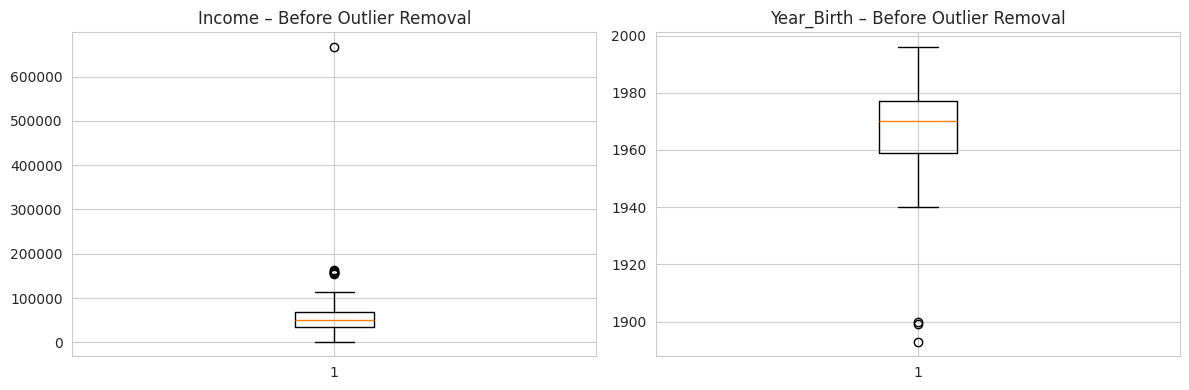

Income max: 666666.0
Year_Birth min: 1893


In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['Income'].dropna())
axes[0].set_title('Income – Before Outlier Removal')
axes[1].boxplot(df['Year_Birth'].dropna())
axes[1].set_title('Year_Birth – Before Outlier Removal')
plt.tight_layout()
plt.show()

print('Income max:', df['Income'].max())
print('Year_Birth min:', df['Year_Birth'].min())

In [85]:
rows_before = len(df)

# Income outlier
# Max income = 666,666 over 4x the 99th percentile. Likely a data entry error.
# Decision: cap at the 99th percentile.
income_99 = df['Income'].quantile(0.99)
df = df[df['Income'] <= income_99]
print(f'Income capped at 99th pct ({income_99:,.0f}): removed {rows_before - len(df)} rows')

# Year_Birth outlier
# Year_Birth = 1893 implies a customer aged ~130 years — impossible.
# Decision: keep only customers born in 1924 or later (age ≤ 100).
rows_before = len(df)
df = df[df['Year_Birth'] >= 1924]
print(f'Year_Birth < 1924 removed: {rows_before - len(df)} rows')

print(f'\nFinal dataset size: {df.shape[0]} rows × {df.shape[1]} columns')

Income capped at 99th pct (94,441): removed 23 rows
Year_Birth < 1924 removed: 3 rows

Final dataset size: 2210 rows × 27 columns


In [86]:
# Reference year: 2014 (last enrollment date in dataset is June 2014)
df['Age'] = 2014 - df['Year_Birth']
print(df['Age'].describe())

count    2210.000000
mean       45.139367
std        11.684069
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max        74.000000
Name: Age, dtype: float64


### A7. Cleaning Summary
Impute Income missing values with median rather than drop it:
- There is a low rate (< 2%), dropping would waste valid information.
- Imputing preserves the full dataset size for more reliable segmentation later.
- The mean could be distorted by the extreme outlier, so median safer choice.

Transforming Dt_Customer to datetime:
- Python treats it as text by default, making date calculations impossible.
- We need it as a proper date to potentially calculate customer tenure.

Another trasformation with "Alone" -> "Single":
- "Alone" and "Single" they describe the same customer group. Dropping it would cost of losing 3 valid customers with no reason.

Dropping "Absurd" and "YOLO":
- They are clearly not real marital statuses.
- There is no logical category to map them to.
- Only 4 rows (~0.2%), so the loss is negligible.

Drop Income outlier (666,666)
  We dropped (capped at 99th percentile) rather than imputed because:
  - The value is over 7× the median and 4× the 99th percentile — almost certainly a data entry error, not a real customer
  - Keeping it would bias all income-based analysis and clustering
  
Drop Year_Birth before 1924
  - A birth year of 1893 means a customer aged ~130 — biologically impossible
  - No meaningful imputation exists for age — you cannot guess someone's real birth year
  - Only 3 rows affected


---
## Task B – Exploratory Data Analysis (EDA)

In [87]:
df['TotalSpending'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
                       df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])

df['TotalPurchases'] = (df['NumWebPurchases'] + df['NumCatalogPurchases'] +
                        df['NumStorePurchases'] + df['NumDealsPurchases'])

print('TotalSpending stats:')
print(df['TotalSpending'].describe().round(2))

TotalSpending stats:
count    2210.00
mean      599.03
std       597.07
min         5.00
25%        68.00
50%       392.50
75%      1033.00
max      2525.00
Name: TotalSpending, dtype: float64


### B1. Socio-demographic Features vs Total Spending

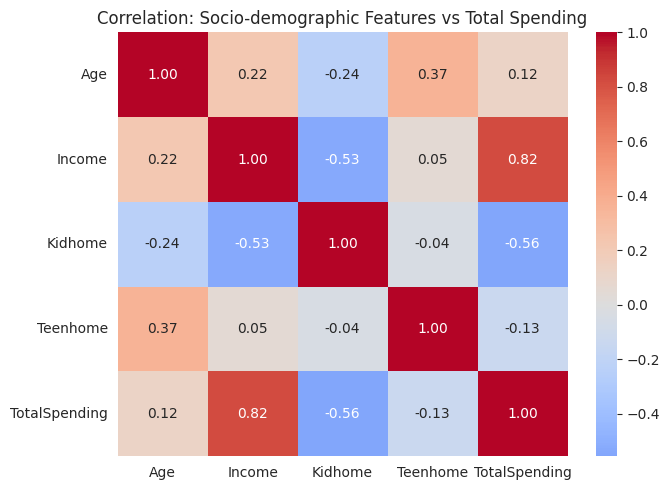

Correlation with TotalSpending:
Income      0.820910
Age         0.121798
Teenhome   -0.133146
Kidhome    -0.555684
Name: TotalSpending, dtype: float64


In [88]:
# Using correlation matrix numerical socio-demographic features vs totalspending
corr_cols = ['Age', 'Income', 'Kidhome', 'Teenhome', 'TotalSpending']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation: Socio-demographic Features vs Total Spending')
plt.tight_layout()
plt.show()

print('Correlation with TotalSpending:')
print(corr_matrix['TotalSpending'].drop('TotalSpending').sort_values(ascending=False))

/tmp/ipykernel_6195/1897101957.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Education', y='TotalSpending', order=edu_order, palette='Blues')


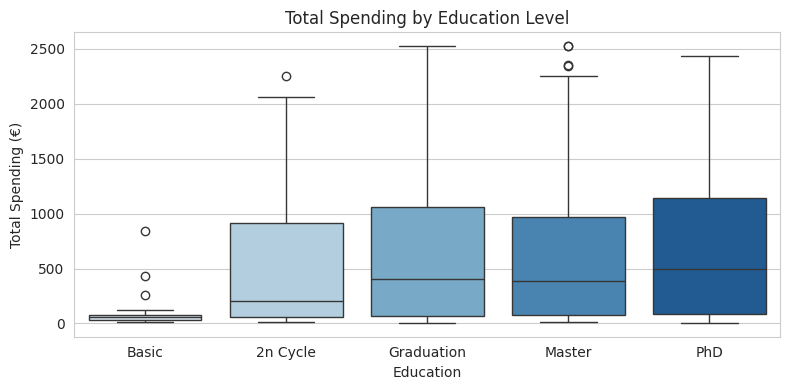

/tmp/ipykernel_6195/1897101957.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Marital_Status', y='TotalSpending', palette='Greens')


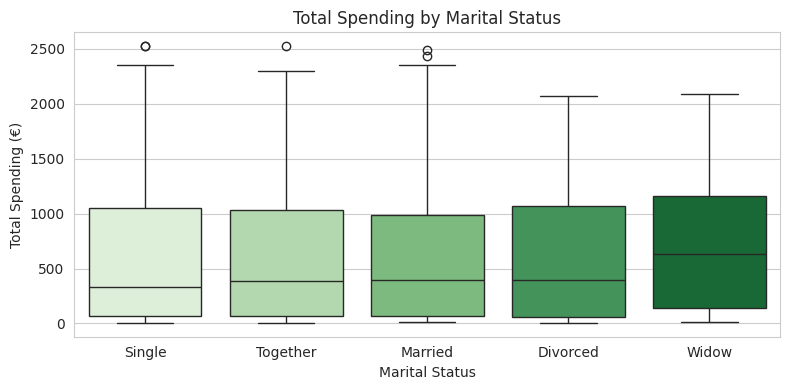

In [89]:
#using education level and marital status both are socio-demographic features.

# Spending by Education level
edu_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Education', y='TotalSpending', order=edu_order, palette='Blues')
plt.title('Total Spending by Education Level')
plt.xlabel('Education')
plt.ylabel('Total Spending (€)')
plt.tight_layout()
plt.show()

# Spending by Marital Status
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Marital_Status', y='TotalSpending', palette='Greens')
plt.title('Total Spending by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Total Spending (€)')
plt.tight_layout()
plt.show()

### B2. Purchase Channel Distribution

/tmp/ipykernel_6195/4182813494.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melt, x='Channel', y='Purchases', ax=axes[1], palette='Set2')


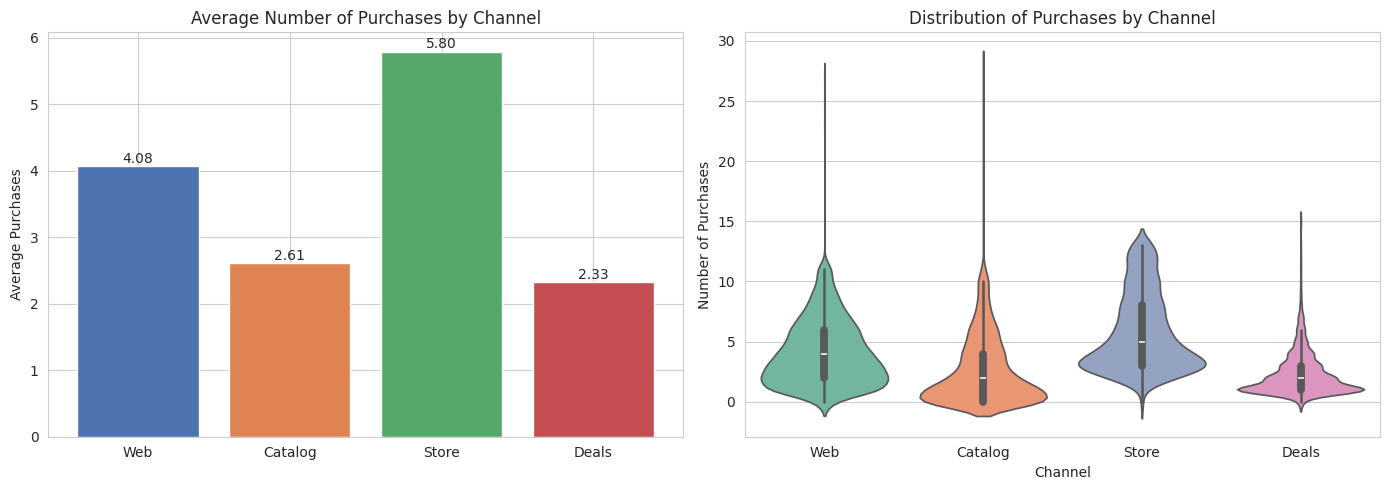

Average purchases per channel:
  Web: 4.08
  Catalog: 2.61
  Store: 5.80
  Deals: 2.33


In [90]:
channels = {
    'Web': df['NumWebPurchases'].mean(),
    'Catalog': df['NumCatalogPurchases'].mean(),
    'Store': df['NumStorePurchases'].mean(),
    'Deals': df['NumDealsPurchases'].mean()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average purchases per channel
axes[0].bar(channels.keys(), channels.values(), color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[0].set_title('Average Number of Purchases by Channel')
axes[0].set_ylabel('Average Purchases')
for i, (k, v) in enumerate(channels.items()):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

# Distribution of purchases per channel (violin)
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']
df_melt = df[channel_cols].melt(var_name='Channel', value_name='Purchases')
df_melt['Channel'] = df_melt['Channel'].str.replace('Num', '').str.replace('Purchases', '').str.strip()
sns.violinplot(data=df_melt, x='Channel', y='Purchases', ax=axes[1], palette='Set2')
axes[1].set_title('Distribution of Purchases by Channel')
axes[1].set_ylabel('Number of Purchases')

plt.tight_layout()
plt.show()

print('Average purchases per channel:')
for k, v in channels.items():
    print(f'  {k}: {v:.2f}')

### B3. Communication Insight – Hidden Trend

/tmp/ipykernel_6195/698365327.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='HasChildren', y='TotalSpending', ax=axes[0], palette='Set1', errorbar='ci')
/tmp/ipykernel_6195/698365327.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='HasChildren', y='NumWebVisitsMonth', ax=axes[1], palette='Set1', errorbar='ci')
/tmp/ipykernel_6195/698365327.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='HasChildren', y='NumWebPurchases', ax=axes[2], palette='Set1', errorbar='ci')


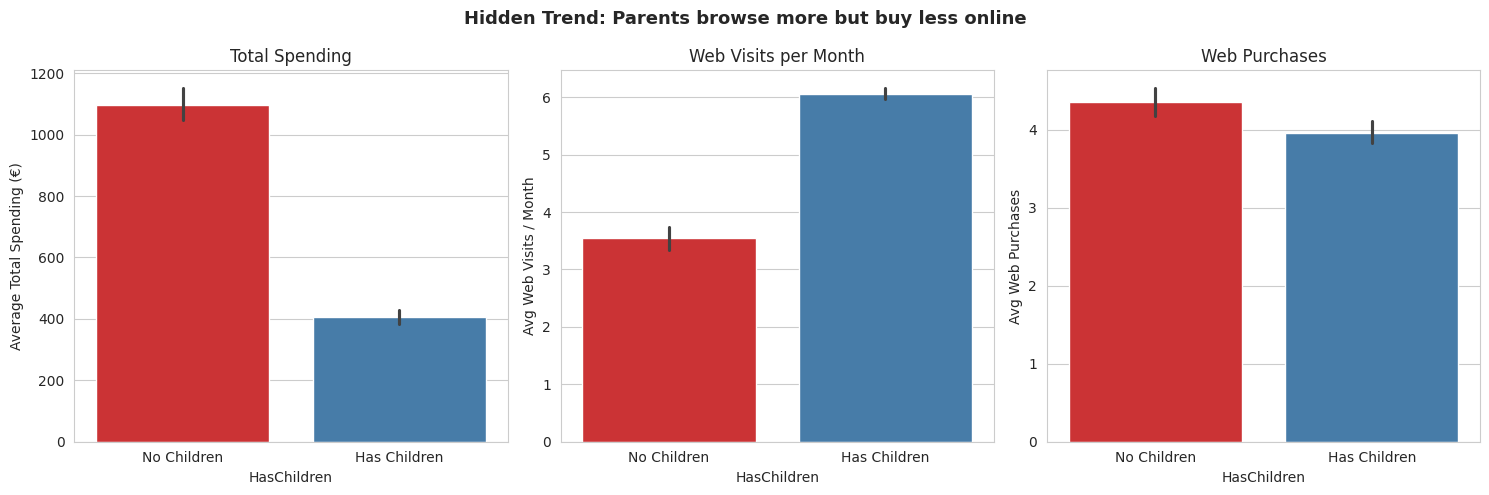

              TotalSpending  NumWebVisitsMonth  NumWebPurchases
HasChildren                                                    
Has Children         405.65               6.06             3.97
No Children         1097.17               3.54             4.36


In [91]:
# Hidden trend: customers with children at home spend significantly less, yet visit the website MORE often, high web traffic but low conversion.
# Opportunity: targeted discount campaigns via web for parents.

df['HasChildren'] = ((df['Kidhome'] + df['Teenhome']) > 0).map({True: 'Has Children', False: 'No Children'})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(data=df, x='HasChildren', y='TotalSpending', ax=axes[0], palette='Set1', errorbar='ci')
axes[0].set_title('Total Spending')
axes[0].set_ylabel('Average Total Spending (€)')

sns.barplot(data=df, x='HasChildren', y='NumWebVisitsMonth', ax=axes[1], palette='Set1', errorbar='ci')
axes[1].set_title('Web Visits per Month')
axes[1].set_ylabel('Avg Web Visits / Month')

sns.barplot(data=df, x='HasChildren', y='NumWebPurchases', ax=axes[2], palette='Set1', errorbar='ci')
axes[2].set_title('Web Purchases')
axes[2].set_ylabel('Avg Web Purchases')

plt.suptitle('Hidden Trend: Parents browse more but buy less online', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

summary = df.groupby('HasChildren')[['TotalSpending','NumWebVisitsMonth','NumWebPurchases']].mean().round(2)
print(summary)

## Summary

### Socio-demographics vs Total Spending.

After analyzing the correlation matrix and boxplot we can say that:
- Income is the strongest predictor of spending. The higher the income, the more customersspend (strong positive correlation).
- Age has a mild positive correlation. Older customers tend to spend slightly mor.e
- Children (Kidhome + Teenhome) have a negative effect. Customers with kids spend significantly less.
- Education matters. PhD and Master customers spend more than Basic or 2n Cycle, which aligns with the income-education link.
- Marital status shows that single and divorced customers tend to spend slightly more than married ones, possibly because they have fewer shared financial responsibilities.

### Purchase Channel Distribution
  
- Store is the dominant channel (avg 5.80 purchases), customers still prefer physical shopping.
- Web is second (4.08), a strong online presence exists but hasn't overtaken in-store.
- Catalog and Deals are low, catalogue shopping is declining, and discount-driven (deals) purchases are not the main behaviour.

###  Hidden Trend
  
- Customers with children visit the website ~40% more than those without, yet they buy less.
  online and spend less overall
- This gap between browsing and buying signals an issue specifically for people who have children.
- Marketing opportunity: targeted web promotions (i.e. family bundles, kids product discounts) could convert these high-traffic to high-spend customers.

---
## Task C – RFM Calculation & Heuristic Segmentation

### C1. RFM Feature Engineering

In [92]:
# R Recency: already in dataset (days since last purchase)
# F Frequency: total number of purchases across all channels
# M Monetary: total amount spent across all product categories

rfm = df[['ID']].copy()
rfm['Recency']   = df['Recency']
rfm['Frequency'] = df['TotalPurchases']
rfm['Monetary']  = df['TotalSpending']

print('RFM features:')
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

RFM features:
       Recency  Frequency  Monetary
count  2210.00    2210.00   2210.00
mean     49.21      14.81    599.03
std      28.92       7.62    597.07
min       0.00       0.00      5.00
25%      24.00       8.00     68.00
50%      50.00      15.00    392.50
75%      74.00      21.00   1033.00
max      99.00      43.00   2525.00


### C2. Quintile Scoring

In [93]:
# For Recency: lower is better (bought recently), so we reverse the score
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(rfm[['Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Total']].head(10))

   Recency  Frequency  Monetary  R_Score  F_Score  M_Score  RFM_Total
0       58         25      1617        3        5        5         13
1       38          6        27        4        1        1          6
2       26         21       776        4        4        4         12
3       26          8        53        4        2        1          7
4       94         19       422        1        4        3          8
5       16         22       716        5        4        4         13
6       34         21       590        4        4        3         11
7       32         10       169        4        2        2          8
8       19          6        46        5        1        1          7
9       68          2        49        2        1        1          4


### C3. Heuristic Segmentation (5 Segments)

Segment
At Risk            536
Lost / Inactive    521
Loyal Customers    515
New / Promising    363
Champions          275
Name: count, dtype: int64


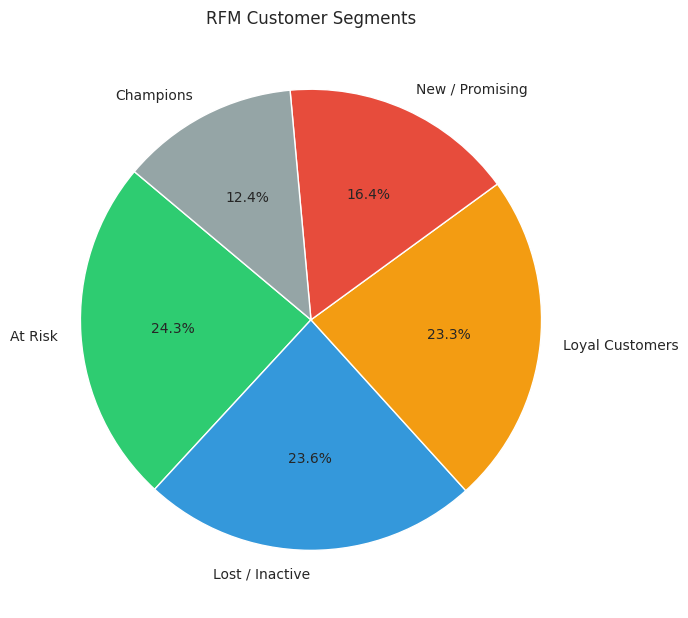

In [94]:
def rfm_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New / Promising'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    else:
        return 'Lost / Inactive'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

seg_counts = rfm['Segment'].value_counts()
print(seg_counts)

plt.figure(figsize=(7, 7))
plt.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
        colors=['#2ecc71','#3498db','#f39c12','#e74c3c','#95a5a6'], startangle=140)
plt.title('RFM Customer Segments')
plt.tight_layout()
plt.show()

### Summary C

Each customer gets 3 scores from 1 to 5 (quintiles):

  - R (Recency) how recently they bought, 5 = very recently, 1 = a long time ago
  - F (Frequency) how often they buy, 5 = very often, 1 = rarely
  - M (Monetary) how much they spend, 5 = high spender, 1 = low spender

  With 5 segments behind: champions, loyal customers, new / promising, at risk, lost / inactive.

 RFM Heuristic Segmentation were used because the main idea of heuristic is to define rules manually by logic, not by algorithm. We decide the thresholds (i.e. R ≥ 4) based on business intuition.

---
## Task D – Unsupervised Learning (K-Means Cluster Analysis)

### D1. Feature Preparation & Scaling

In [95]:
# Use RFM values + Age + Income for richer clustering
cluster_features = ['Recency', 'TotalPurchases', 'TotalSpending', 'Age', 'Income']
X = df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features used for clustering:', cluster_features)
print('Scaled array shape:', X_scaled.shape)

Features used for clustering: ['Recency', 'TotalPurchases', 'TotalSpending', 'Age', 'Income']
Scaled array shape: (2210, 5)


### D2. Optimal k – Elbow Method & Silhouette Score



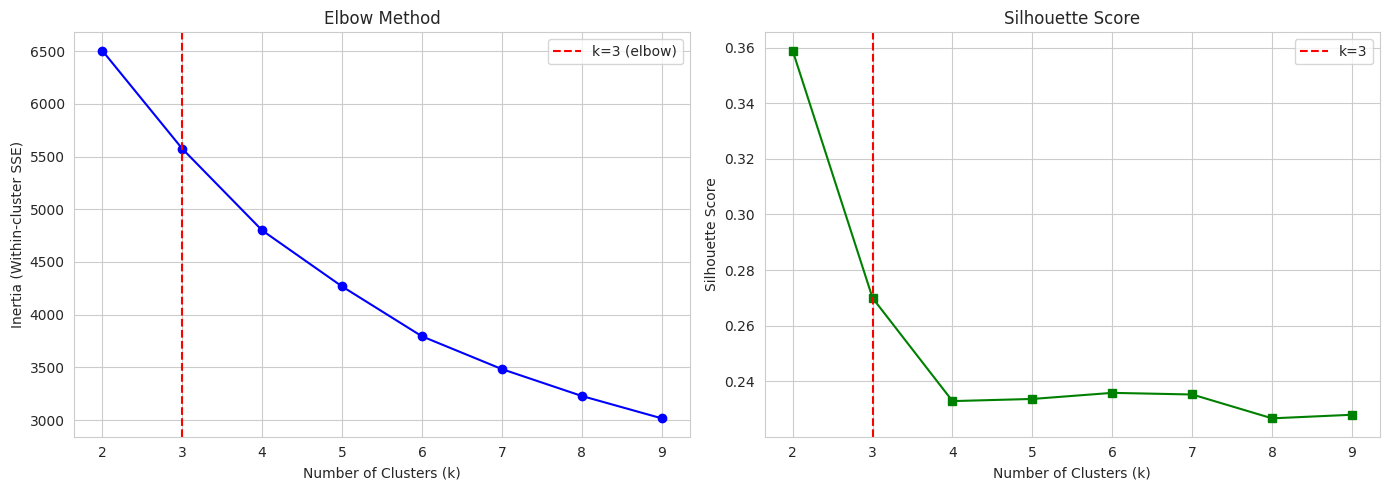

Silhouette scores by k:
  k=2: 0.3589
  k=3: 0.2699
  k=4: 0.2329
  k=5: 0.2336
  k=6: 0.2358
  k=7: 0.2352
  k=8: 0.2267
  k=9: 0.2280


In [96]:
inertias, silhouettes = [], []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].axvline(x=3, color='red', linestyle='--', label='k=3 (elbow)')
axes[0].legend()

axes[1].plot(k_range, silhouettes, 'gs-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=3, color='red', linestyle='--', label='k=3')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Silhouette scores by k:')
for k, s in zip(k_range, silhouettes):
    print(f'  k={k}: {s:.4f}')

### D3. Final K-Means Model (k=3)

Cluster Profiles:
         Recency  TotalPurchases  TotalSpending    Age    Income
Cluster                                                         
0          75.22            9.73         163.49  44.69  38202.51
1          48.90           21.69        1162.95  47.68  69426.88
2          24.59            8.93         136.43  41.59  35490.56


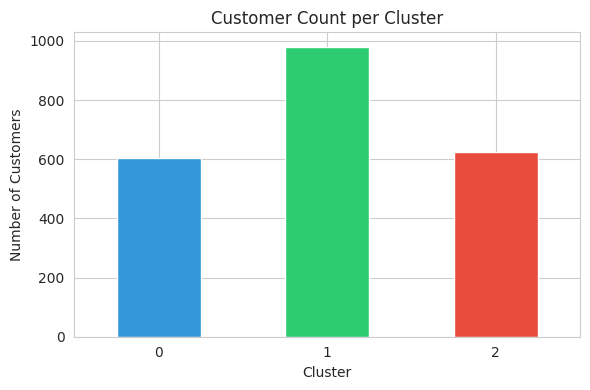

In [97]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

# Profile each cluster
cluster_profile = df.groupby('Cluster')[cluster_features].mean().round(2)
print('Cluster Profiles:')
print(cluster_profile)

plt.figure(figsize=(6, 4))
df['Cluster'].value_counts().sort_index().plot(kind='bar', color=['#3498db','#2ecc71','#e74c3c'])
plt.title('Customer Count per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### D4. Cluster vs RFM Segment Comparison

Cluster vs RFM Segment cross-tabulation:
Segment  At Risk  Champions  Lost / Inactive  Loyal Customers  New / Promising
Cluster                                                                       
0            154          0              413               37                0
1            382        272                3              321                2
2              0          3              105              157              361


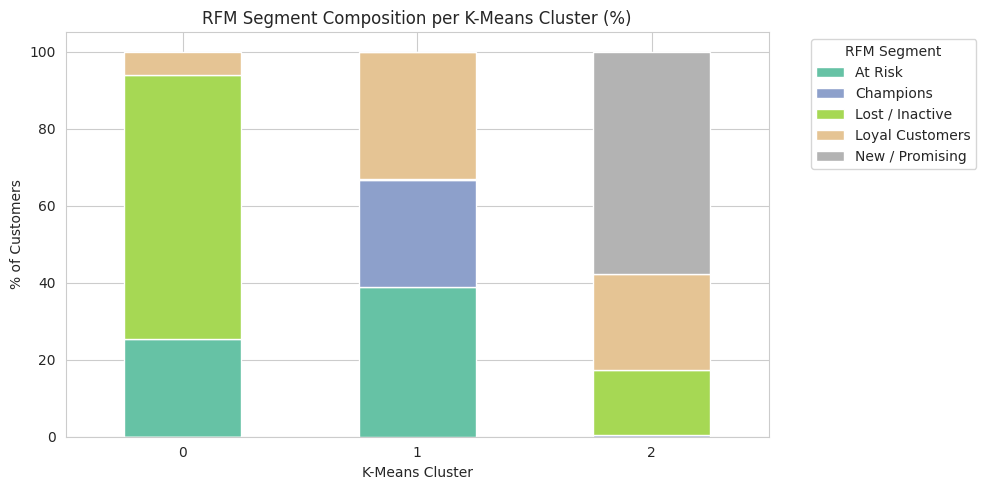

In [98]:
# Merge RFM segments into main df for comparison
df = df.merge(rfm[['ID','Segment']], on='ID', how='left')

crosstab = pd.crosstab(df['Cluster'], df['Segment'])
print('Cluster vs RFM Segment cross-tabulation:')
print(crosstab)

crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
crosstab_pct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10, 5))
plt.title('RFM Segment Composition per K-Means Cluster (%)')
plt.xlabel('K-Means Cluster')
plt.ylabel('% of Customers')
plt.legend(title='RFM Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Summary D

For clustering were used 5 features:
- Recency, TotalPurchases, TotalSpending = the RFM dimensions
- Age, Income = socio-demographic context

Using both methods (both because they complement each other with a clear results) we got k = 3. The reason why, because on k = 2 we have a significantly high results, but using only two clustering couldn't give us a great results in marketing side; k = 4 score drops but gives richer, more actionable segments.

Therefore, k = 3 it's a good compromise for both marketing and statistics, from k=2 to k=3 is the smallest jump after the initial one, 3 clusters gives you something like: **High Value, Mid Value, Low Value** still clear and actionable.


The difference between RFM and K-Means algorithm results is - **RFM** put **Champions** and **At Risk** customers in completely different segments, but **K-Means** put many of them in the same cluster (Cluster 1).

This means they share similar demographic profiles (income, age) even though their recent behaviour differs — which RFM alone would have missed.

**Interpretation:** RFM segments customers purely on purchase behaviour. K-Means captures additional dimensions — Age and Income — revealing that customers in the same RFM segment can belong to different clusters. For example, two "Loyal Customers" might differ greatly in income, requiring different message tones and channel choices.

---
## Task E – Communication Strategy

In [100]:
strategy = {
    'Champions': {
        'Profile': 'High R, F, M — recent, frequent, big spenders',
        'Channel': 'Email + Loyalty App',
        'Tone': 'Exclusive & Rewarding — early access, VIP offers, premium content'
    },
    'Loyal Customers': {
        'Profile': 'Consistent buyers, moderate-high spending',
        'Channel': 'Email Newsletter + Push Notifications',
        'Tone': 'Appreciative & Personal — "Thank you" campaigns, personalised recommendations'
    },
    'New / Promising': {
        'Profile': 'Recent first-time or early buyers, low frequency',
        'Channel': 'Email Onboarding Sequence + Social Media',
        'Tone': 'Welcoming & Educational — introduce product categories, highlight value'
    },
    'At Risk': {
        'Profile': 'Previously active but have not bought recently',
        'Channel': 'Email Re-engagement + SMS',
        'Tone': 'Urgent & Incentive-driven — "We are waiting for you" / "Its been a while... here it is what we have" + time-limited discount'
    },
    'Lost / Inactive': {
        'Profile': 'Low R, F, M — disengaged customers',
        'Channel': 'Low-cost: Email only',
        'Tone': 'Curiosity-based — highlight new products or big seasonal sale'
    }
}

print('=' * 70)
for segment, info in strategy.items():
    print(f"\n SEGMENT: {segment}")
    print(f"  Profile : {info['Profile']}")
    print(f"  Channel : {info['Channel']}")
    print(f"  Tone    : {info['Tone']}")
print('=' * 70)


 SEGMENT: Champions
  Profile : High R, F, M — recent, frequent, big spenders
  Channel : Email + Loyalty App
  Tone    : Exclusive & Rewarding — early access, VIP offers, premium content

 SEGMENT: Loyal Customers
  Profile : Consistent buyers, moderate-high spending
  Channel : Email Newsletter + Push Notifications
  Tone    : Appreciative & Personal — "Thank you" campaigns, personalised recommendations

 SEGMENT: New / Promising
  Profile : Recent first-time or early buyers, low frequency
  Channel : Email Onboarding Sequence + Social Media
  Tone    : Welcoming & Educational — introduce product categories, highlight value

 SEGMENT: At Risk
  Profile : Previously active but have not bought recently
  Channel : Email Re-engagement + SMS
  Tone    : Urgent & Incentive-driven — "We are waiting for you" / "Its been a while... here it is what we have" + time-limited discount

 SEGMENT: Lost / Inactive
  Profile : Low R, F, M — disengaged customers
  Channel : Low-cost: Email only
  Ton